## Setup

In [1]:
import os, random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as F
from torchvision.datasets import CelebA
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

## Data Pipeline

### Transform & Fungsi degrade (for LQ)

In [2]:
img_size = 128

transform = T.Compose([
  T.CenterCrop(178),
  T.Resize((img_size, img_size)),
  T.ToTensor()
])

def degrade(img_tensor):
  # img_tensor: (C,H,W) [0,1]
  # downscale => upscale (blur effect)
  img = F.resize(img_tensor,(img_size//2, img_size//2))
  img = F.resize(img,(img_size,img_size))
  # tambah noise ringan
  noise = 0.02 * torch.rand_like(img)
  img = torch.clamp(img + noise, 0.0, 1.0)
  return img

### Dataset Wrapper (Retur LQ, HQ)

In [3]:
class CelebALocalDataset(Dataset):
  def __init__(self, img_dir, transform,max_samples=2000):
    self.paths = [os.path.join(img_dir,p) for p in os.listdir(img_dir)]
    self.paths = self.paths[:max_samples]
    self.transform = transform
  
  def __len__(self):
    return len(self.paths)

  def __getitem__(self, idx):
    img_path = self.paths[idx]
    img = Image.open(img_path).convert("RGB")

    img = self.transform(img)

    hq = img
    lq = degrade(img)
    return lq, hq
  

### Split train/val + DataLoader

In [4]:
dataset = CelebALocalDataset(img_dir="./data/celeba/img_align_celeba", transform=transform, max_samples=2000)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size,val_size])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=0)

lq,hq = next(iter(train_loader))
print("LQ:", lq.shape, "HQ:", hq.shape)


LQ: torch.Size([8, 3, 128, 128]) HQ: torch.Size([8, 3, 128, 128])


### Visualisasi Cepat

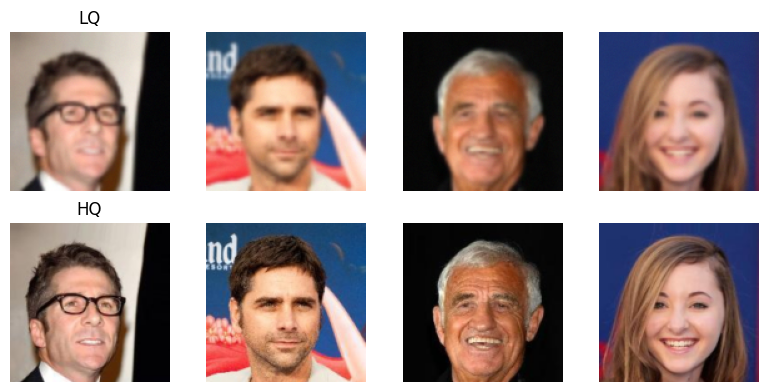

In [5]:
def show_pair(lq,hq, n=4):
  plt.figure(figsize=(8,4))
  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(lq[i].permute(1,2,0).cpu())
    plt.axis("off")
    if i == 0 : plt.title("LQ")
    plt.subplot(2,n,i+1+n)
    plt.imshow(hq[i].permute(1,2,0).cpu())
    plt.axis("off")
    if i == 0: plt.title("HQ")
  plt.tight_layout(); plt.show()

show_pair(lq,hq)

## Baseline Model

In [20]:
class SimpleRestorationCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(3,32,3,padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(32,64,3,padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(64,32,3,padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(32,3,3,padding=1),
      nn.Sigmoid()
    )
  def forward(self,x):
    return self.net(x)
  
model = SimpleRestorationCNN().to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Params: {num_params/1e6:.2f}M")
print(model(torch.randn(1,3,128,128)).shape)

Params: 0.04M
torch.Size([1, 3, 128, 128])


## Training Loop

In [21]:
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model,loader):
  model.train()
  total_loss = 0.0
  for lq,hq in loader:
    lq,hq = lq.to(device), hq.to(device)

    pred = model(lq)
    loss = criterion(pred,hq)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  return total_loss / len(loader)

@torch.no_grad()
def validate(model,loader):
  model.eval()
  total_loss = 0.0
  for lq,hq in loader:
    lq,hq - lq.to(device), hq.to(device)
    pred = model(lq)
    loss = criterion(pred,hq)
    total_loss += loss.item()
  return total_loss / len(loader)

In [22]:
epochs = 2

for ep in range(epochs):
  train_loss = train_one_epoch(model, train_loader)
  val_loss = validate(model, val_loader)
  print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/2 | Train Loss: 0.0605 | Val Loss: 0.0343
Epoch 2/2 | Train Loss: 0.0295 | Val Loss: 0.0326


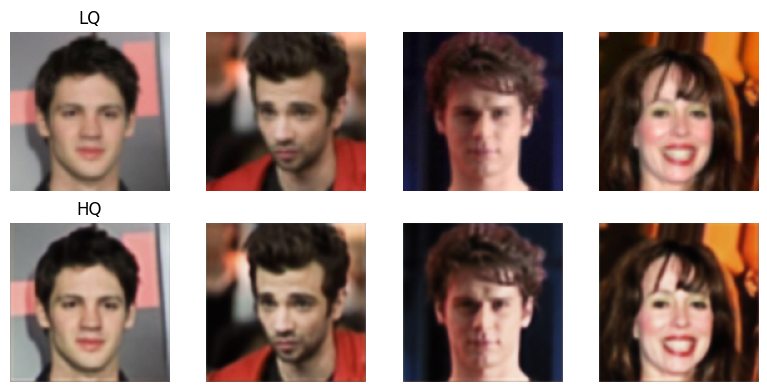

In [24]:
model.eval()
lq,hq = next(iter(val_loader))
lq = lq.to(device)
with torch.no_grad():
  pred = model(lq).cpu()

show_pair(lq.cpu(), pred.cpu(), n=4)